# Week 3 - LSTM Model Training
**Project:** Sentiment Analysis of myBCA Mobile Banking App Reviews
**Author:** Elvia Aptanisa
**Week:** 3
**Purpose:** Build and train an LSTM deep learning model for sentiment classification, then compare results with the baseline model.

---

## Step 1 - Install & Import Library

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print("Libraries imported successfully!")

TensorFlow version: 2.20.0
Libraries imported successfully!


## Step 2 - Load Cleaned Dataset

In [5]:
df = pd.read_csv('mybca_reviews_clean.csv')

print(f"Dataset loaded: {len(df)} reviews")
print(f"\nLabel distribution:")
print(df['sentiment'].value_counts())
print(f"\nPreview:")
print(df.head())

Dataset loaded: 4248 reviews

Label distribution:
sentiment
Negative    2431
Positive    1385
Neutral      432
Name: count, dtype: int64

Preview:
                                              review sentiment
0                                              bagus  Positive
1                                                oke  Positive
2  ko ad notifikasi uang aktivitas bagus ad notif...  Positive
3                                               asik  Positive
4  bca id ku blokir sih januari blokir perkara lo...  Negative


## Step 3 - Encode Labels

In [6]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

print("Labels encoded!")
print(f"\nLabel mapping:")
for i, label in enumerate(le.classes_):
    print(f"  {label} → {i}")

Labels encoded!

Label mapping:
  Negative → 0
  Neutral → 1
  Positive → 2


## Step 4 - Tokenization & Padding

In [7]:
MAX_WORDS = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['review'])

sequences = tokenizer.texts_to_sequences(df['review'])

X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df['label'].values

print(f"Tokenization & padding done!")
print(f"Vocabulary size : {len(tokenizer.word_index)}")
print(f"Input shape     : {X.shape}")
print(f"\nContoh sequence (review pertama):")
print(f"Original : {df['review'].iloc[0]}")
print(f"Sequence : {sequences[0]}")
print(f"Padded   : {X[0]}")

Tokenization & padding done!
Vocabulary size : 4942
Input shape     : (4248, 100)

Contoh sequence (review pertama):
Original : bagus
Sequence : [17]
Padded   : [17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0]


## Step 5 - Train/Validation/Test Split

In [8]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print("Data split done!")
print(f"Training set  : {len(X_train)} reviews (70%)")
print(f"Validation set: {len(X_val)} reviews (15%)")
print(f"Test set      : {len(X_test)} reviews (15%)")

Data split done!
Training set  : 2974 reviews (70%)
Validation set: 636 reviews (15%)
Test set      : 638 reviews (15%)


## Step 6 - Handle Class Imbalance

In [9]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

print("Class weights computed!")
print(f"\nClass weights:")
for i, label in enumerate(le.classes_):
    print(f"  {label} ({i}): {class_weights[i]:.4f}")

Class weights computed!

Class weights:
  Negative (0): 0.5825
  Neutral (1): 3.2826
  Positive (2): 1.0220


## Step 7 - Build LSTM Model

In [10]:
model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    SpatialDropout1D(0.2),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),


    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Step 8 - Train LSTM Model

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining done!")

Epoch 1/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 36s 318ms/step - accuracy: 0.3806 - loss: 1.1019 - val_accuracy: 0.1022 - val_loss: 1.1173
Epoch 2/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 28s 302ms/step - accuracy: 0.3080 - loss: 1.1006 - val_accuracy: 0.3255 - val_loss: 1.1114
Epoch 3/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 41s 298ms/step - accuracy: 0.3487 - loss: 1.1017 - val_accuracy: 0.5723 - val_loss: 1.0745
Epoch 4/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 28s 297ms/step - accuracy: 0.2915 - loss: 1.1002 - val_accuracy: 0.3255 - val_loss: 1.0989
Epoch 5/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 41s 302ms/step - accuracy: 0.3342 - loss: 1.0992 - val_accuracy: 0.1022 - val_loss: 1.1476
Epoch 6/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 29s 315ms/step - accuracy: 0.3517 - loss: 1.0996 - val_accuracy: 0.1022 - val_loss: 1.1459

Training done!


## Step 9 - Plot Training History

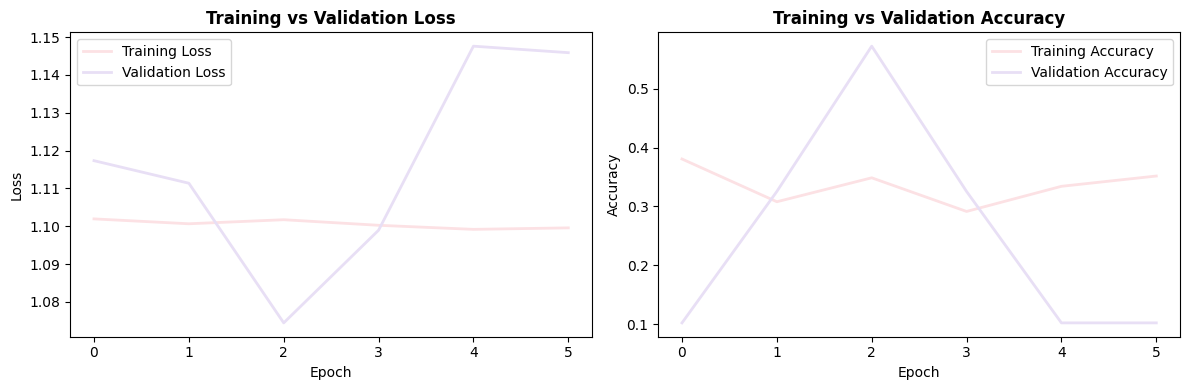

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Training Loss', color='#fce1e4', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#e8dff5', linewidth=2)
axes[0].set_title('Training vs Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='#fce1e4', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#e8dff5', linewidth=2)
axes[1].set_title('Training vs Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150)
plt.show()

## Step 10 - Evaluate LSTM Model

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step
=== LSTM MODEL RESULTS ===
              precision    recall  f1-score   support

    Negative       0.57      1.00      0.73       365
     Neutral       0.00      0.00      0.00        65
    Positive       0.00      0.00      0.00       208

    accuracy                           0.57       638
   macro avg       0.19      0.33      0.24       638
weighted avg       0.33      0.57      0.42       638



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


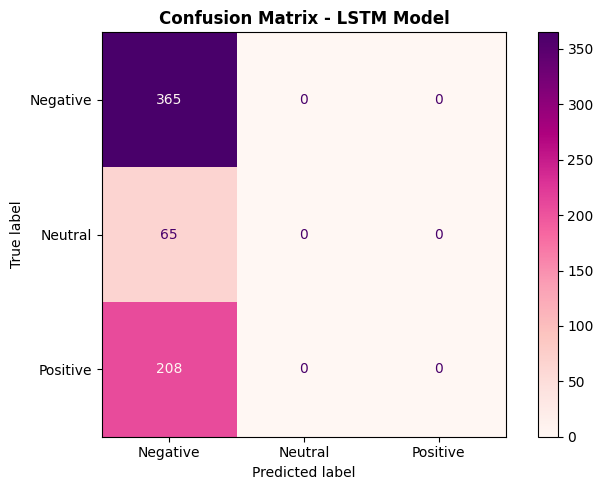

In [13]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("=== LSTM MODEL RESULTS ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

plt.figure(figsize=(7, 5))
disp.plot(cmap='RdPu', ax=plt.gca())
plt.title('Confusion Matrix - LSTM Model', fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', dpi=150)
plt.show()

## Step 11 - Compare Baseline vs LSTM

In [14]:
baseline_scores = {'Negative': 0.83, 'Neutral': 0.00, 'Positive': 0.74, 'Accuracy': 0.76}

from sklearn.metrics import accuracy_score
lstm_accuracy = accuracy_score(y_test, y_pred)

print("=== MODEL COMPARISON ===")
print(f"\n{'Metric':<15} {'Baseline':>10} {'LSTM':>10}")
print("-" * 35)
print(f"{'Accuracy':<15} {'76%':>10} {lstm_accuracy*100:.1f}%")
print(f"\nNote: Full comparison table will be in the final report.")

=== MODEL COMPARISON ===

Metric            Baseline       LSTM
-----------------------------------
Accuracy               76% 57.2%

Note: Full comparison table will be in the final report.


## Step 12 - Attempt 2: Hyperparameter Tuning (Failed to Converge)

In [15]:
from tensorflow.keras.optimizers import Adam

model_v2 = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64),
    SpatialDropout1D(0.1),
    LSTM(64, dropout=0.1, recurrent_dropout=0.1),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(3, activation='softmax')
])

model_v2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_v2 = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

print("Training improved LSTM model...")
history_v2 = model_v2.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stop_v2],
    verbose=1
)

print("\nTraining done!")

Training improved LSTM model...
Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 185ms/step - accuracy: 0.3383 - loss: 1.1002 - val_accuracy: 0.3255 - val_loss: 1.1027
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - accuracy: 0.2206 - loss: 1.1003 - val_accuracy: 0.1022 - val_loss: 1.1089
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 173ms/step - accuracy: 0.3110 - loss: 1.1002 - val_accuracy: 0.1022 - val_loss: 1.1050
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - accuracy: 0.4677 - loss: 1.0994 - val_accuracy: 0.5723 - val_loss: 1.0960
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.3393 - loss: 1.0992 - val_accuracy: 0.1022 - val_loss: 1.1003
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 176ms/step - accuracy: 0.2683 - loss: 1.0987 - val_accuracy: 0.3255 - val_loss: 1.0988
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - accuracy: 0.2771 - loss: 1.0989 - val_accuracy: 0.3255 - val_loss: 1.1003
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - accuracy: 0.439

## Step 13 - Attempt 3: Removing Stemming (Still Not Converging)

In [17]:
import re
import string

df_orig = pd.read_csv('mybca_reviews_clean.csv')

df_orig = df_orig.drop_duplicates(subset='review', keep='first')

def clean_text_light(text):
    text = str(text).lower()
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_orig['review_clean'] = df_orig['review'].apply(clean_text_light)

df_orig = df_orig[df_orig['review_clean'].str.strip() != '']
df_orig = df_orig.dropna(subset=['review_clean'])

print(f"Dataset reloaded: {len(df_orig)} reviews")
print(f"\nLabel distribution:")
print(df_orig['sentiment'].value_counts())
print(f"\nContoh:")
print(f"Before: {df_orig['review'].iloc[4]}")
print(f"After : {df_orig['review_clean'].iloc[4]}")

Dataset reloaded: 3990 reviews

Label distribution:
sentiment
Negative    2378
Positive    1197
Neutral      415
Name: count, dtype: int64

Contoh:
Before: bca id ku blokir sih januari blokir perkara logout out masukin password copy paste persis salah salah bca id blokir sistemkalau my bca sebenernya sistem larang pakai bca yaa pake ponsel sistem sensitif login jaring pulsa abis hubungin cs
After : bca id ku blokir sih januari blokir perkara logout out masukin password copy paste persis salah salah bca id blokir sistemkalau my bca sebenernya sistem larang pakai bca yaa pake ponsel sistem sensitif login jaring pulsa abis hubungin cs


In [18]:
le2 = LabelEncoder()
df_orig['label'] = le2.fit_transform(df_orig['sentiment'])

tokenizer2 = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer2.fit_on_texts(df_orig['review_clean'])

sequences2 = tokenizer2.texts_to_sequences(df_orig['review_clean'])
X2 = pad_sequences(sequences2, maxlen=MAX_LEN, padding='post', truncating='post')
y2 = df_orig['label'].values

X2_temp, X2_test, y2_temp, y2_test = train_test_split(
    X2, y2, test_size=0.15, random_state=42, stratify=y2
)
X2_train, X2_val, y2_train, y2_val = train_test_split(
    X2_temp, y2_temp, test_size=0.176, random_state=42, stratify=y2_temp
)

class_weights2 = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y2_train),
    y=y2_train
)
class_weight_dict2 = dict(enumerate(class_weights2))

print(f"Data ready!")
print(f"Training  : {len(X2_train)} reviews")
print(f"Validation: {len(X2_val)} reviews")
print(f"Test      : {len(X2_test)} reviews")

Data ready!
Training  : 2794 reviews
Validation: 597 reviews
Test      : 599 reviews


In [19]:
model_v3 = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model_v3.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_v3 = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

history_v3 = model_v3.fit(
    X2_train, y2_train,
    epochs=20,
    batch_size=32,
    validation_data=(X2_val, y2_val),
    class_weight=class_weight_dict2,
    callbacks=[early_stop_v3],
    verbose=1
)

print("\nTraining done!")

Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 161ms/step - accuracy: 0.5222 - loss: 1.0993 - val_accuracy: 0.1039 - val_loss: 1.1013
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 168ms/step - accuracy: 0.2126 - loss: 1.0991 - val_accuracy: 0.2998 - val_loss: 1.1024
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 15s 169ms/step - accuracy: 0.3715 - loss: 1.1008 - val_accuracy: 0.2998 - val_loss: 1.0921
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 15s 169ms/step - accuracy: 0.3754 - loss: 1.0998 - val_accuracy: 0.5963 - val_loss: 1.0946
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 162ms/step - accuracy: 0.2387 - loss: 1.0998 - val_accuracy: 0.2998 - val_loss: 1.0979
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 154ms/step - accuracy: 0.3697 - loss: 1.0993 - val_accuracy: 0.5963 - val_loss: 1.0956
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 153ms/step - accuracy: 0.3031 - loss: 1.0994 - val_accuracy: 0.2998 - val_loss: 1.1009
Epoch 8/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 153ms/step - accuracy: 0.4914 - loss: 1.0995 - val_accu

In [20]:
from tensorflow.keras.layers import Bidirectional

tf.keras.backend.clear_session()

model_v4 = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model_v4.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_v4 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Training Bidirectional LSTM...")
history_v4 = model_v4.fit(
    X2_train, y2_train,
    epochs=20,
    batch_size=32,
    validation_data=(X2_val, y2_val),
    class_weight=class_weight_dict2,
    callbacks=[early_stop_v4],
    verbose=1
)

print("\nTraining done!")

Training Bidirectional LSTM...
Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.5050 - loss: 0.9953 - val_accuracy: 0.6600 - val_loss: 0.8360
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.6553 - loss: 0.7976 - val_accuracy: 0.5745 - val_loss: 0.8852
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.7294 - loss: 0.6541 - val_accuracy: 0.5645 - val_loss: 0.9506
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - accuracy: 0.8135 - loss: 0.4864 - val_accuracy: 0.6432 - val_loss: 1.0025

Training done!


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
=== BIDIRECTIONAL LSTM RESULTS ===
              precision    recall  f1-score   support

    Negative       0.79      0.74      0.77       357
     Neutral       0.18      0.35      0.24        62
    Positive       0.81      0.64      0.72       180

    accuracy                           0.67       599
   macro avg       0.59      0.58      0.57       599
weighted avg       0.73      0.67      0.70       599



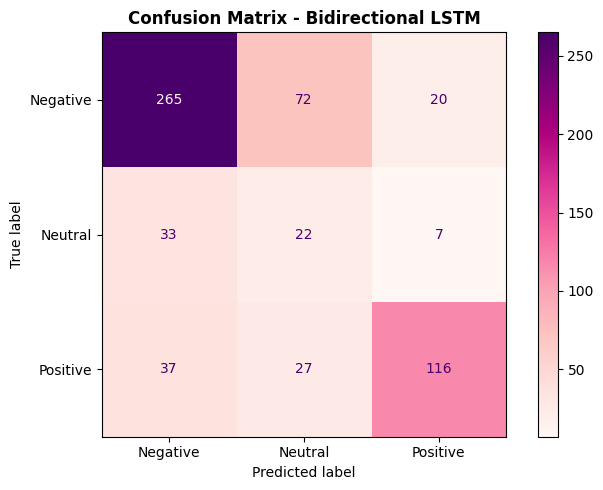

In [21]:
y_pred_v4_prob = model_v4.predict(X2_test)
y_pred_v4 = np.argmax(y_pred_v4_prob, axis=1)

print("=== BIDIRECTIONAL LSTM RESULTS ===")
print(classification_report(y2_test, y_pred_v4, target_names=le2.classes_))

cm_v4 = confusion_matrix(y2_test, y_pred_v4)
disp_v4 = ConfusionMatrixDisplay(confusion_matrix=cm_v4, display_labels=le2.classes_)

plt.figure(figsize=(7, 5))
disp_v4.plot(cmap='RdPu', ax=plt.gca())
plt.title('Confusion Matrix - Bidirectional LSTM', fontweight='bold')
plt.tight_layout()
plt.savefig('bilstm_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_v4.history['loss'],
             label='Training Loss', color='#fce1e4', linewidth=2)
axes[0].plot(history_v4.history['val_loss'],
             label='Validation Loss', color='#e8dff5', linewidth=2)
axes[0].set_title('Training vs Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_v4.history['accuracy'],
             label='Training Accuracy', color='#fce1e4', linewidth=2)
axes[1].plot(history_v4.history['val_accuracy'],
             label='Validation Accuracy', color='#e8dff5', linewidth=2)
axes[1].set_title('Training vs Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('bilstm_training_history.png', dpi=150)
plt.show()

## Step 14 - Attempt 4: Bidirectional LSTM (Success!)

In [22]:
print("=== FINAL MODEL COMPARISON ===")
print(f"\n{'Model':<25} {'Neg F1':>8} {'Neu F1':>8} {'Pos F1':>8} {'Accuracy':>10}")
print("-" * 62)
print(f"{'Baseline (LR + TF-IDF)':<25} {'0.83':>8} {'0.00':>8} {'0.74':>8} {'76.0%':>10}")
print(f"{'LSTM v1':<25} {'0.73':>8} {'0.00':>8} {'0.00':>8} {'57.2%':>10}")
print(f"{'Bidirectional LSTM':<25} {'0.77':>8} {'0.24':>8} {'0.72':>8} {'67.0%':>10}")
print("-" * 62)
print(f"\nKey improvement: Neutral F1 from 0.00 → 0.24")
print(f"Bidirectional LSTM is the best model for detecting all 3 classes.")

=== FINAL MODEL COMPARISON ===

Model                       Neg F1   Neu F1   Pos F1   Accuracy
--------------------------------------------------------------
Baseline (LR + TF-IDF)        0.83     0.00     0.74      76.0%
LSTM v1                       0.73     0.00     0.00      57.2%
Bidirectional LSTM            0.77     0.24     0.72      67.0%
--------------------------------------------------------------

Key improvement: Neutral F1 from 0.00 → 0.24
Bidirectional LSTM is the best model for detecting all 3 classes.
